In [115]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

from dotenv import load_dotenv



In [116]:
# defining the graph state
class QuadState(TypedDict):
    a: int
    b: int
    c: int

    equation: str
    discriminant: float
    result: int


In [171]:
# creating the function that shows the equation
def show_equation(state: QuadState):
    equation = f"{state['a']}x2 {state['b']:+}x {state['c']:+}"
    equation = equation.replace('+', '+ ')
    equation = equation.replace('-', '- ')


    return {'equation': equation}

In [172]:
# Calculating the discriminant of the function
def calculate_discriminant(state: QuadState):
    discriminant = state['b']**2 - (4*state['a']*state['c'])
    return {'discriminant': discriminant}

In [173]:
def no_real_root(state: QuadState):
    result= f'no real roots'

    return {'result': result}


In [174]:
def real_roots(state: QuadState):
    root1 = (-state['b'] + state['discriminant'] ** 0.5)/(2*state['a'])
    root2 = (-state['b'] - state['discriminant'] ** 0.5)/(2*state['a'])

    result =  f'the roots are {root1} and {root2}'

    return {'result': result}



In [175]:
def repeated_roots(state: QuadState):
    root = (-state['b'])/(2*state['a'])
    result  = f'only repeating root is {root}'

    return {'result': result}

In [176]:
# cheack Condition
def check_condition(state: QuadState) -> Literal['real_roots', 'repeated_roots', 'no_real_root']:

    if state['discriminant'] > 0:
        return 'real_roots'
    elif state['discriminant'] == 0:
        return 'repeated_roots'
    else:
        return 'no_real_root'

In [177]:
# defining a graph
graph = StateGraph(QuadState)

# defining nodes
graph.add_node('show_equation', show_equation)
graph.add_node('calculate_discriminant', calculate_discriminant)
graph.add_node('no_real_root', no_real_root)
graph.add_node('real_roots', real_roots)
graph.add_node('repeated_roots', repeated_roots)


# defining edges
graph.add_edge(START, 'show_equation')
graph.add_edge('show_equation', 'calculate_discriminant')


graph.add_conditional_edges('calculate_discriminant', check_condition)


graph.add_edge('real_roots', END)
graph.add_edge('repeated_roots', END)
graph.add_edge('no_real_root', END)




# compiling the graph
workflow = graph.compile()

#executing the graph


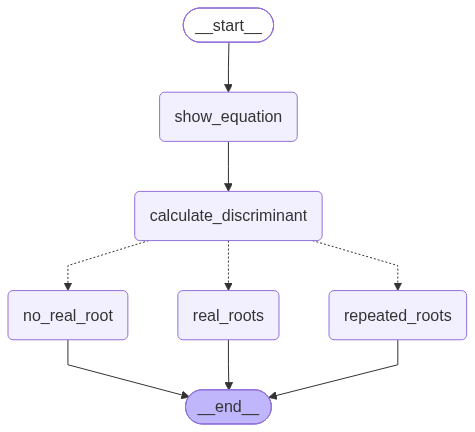

In [178]:
workflow

In [ ]:
initial_state = {
    'a': 2,
    'b': -4,
    'c': 2
}
workflow.invoke(initial_state)

{'a': 2,
 'b': 4,
 'c': -2,
 'equation': '2x2 + 4x - 2',
 'discriminant': 32,
 'result': 'the roots are 0.41421356237309515 and -2.414213562373095'}